In [1]:

import subprocess
subprocess.run(["py", "-m", "pip", "install", "requests", "pandas"], capture_output=True)
print("Libraries ready ✓")

Libraries ready ✓


In [2]:
import requests
import pandas as pd

# Uasin Gishu coordinates (Eldoret centre)
LAT = 0.5204
LON = 35.2699

# Parameters to download
params = ",".join([
    "PRECTOTCORR",      # Rainfall (mm)
    "T2M",              # Temperature avg (°C)
    "T2M_MAX",          # Temperature max (°C)
    "T2M_MIN",          # Temperature min (°C)
    "ALLSKY_SFC_SW_DWN",# Solar radiation
    "RH2M",             # Humidity (%)
    "GWETROOT"          # Soil wetness (0-1)
])

print("Downloading weather data from NASA POWER...")


url = (
    "https://power.larc.nasa.gov/api/temporal/monthly/point"
    f"?parameters={params}"
    "&community=AG"
    f"&longitude={LON}&latitude={LAT}"
    "&start=2005&end=2024"
    "&format=CSV"
)

response = requests.get(url, timeout=90)

# Save raw file
with open("../data/raw/weather_raw.csv", "w") as f:
    f.write(response.text)

print("✓ Raw file saved to data/raw/weather_raw.csv")
print("Preview of response:")
print(response.text[:500])

✓ Raw file saved to data/raw/weather_raw.csv
Preview of response:
-BEGIN HEADER-
NASA/POWER Source Native Resolution Monthly and Annual 
Dates (month/day/year): 01/01/2005 through 12/31/2024 in LST
Location: Latitude  0.5204   Longitude 35.2699 
Elevation from MERRA-2: Average for 0.5 x 0.625 degree lat/lon region = 1809.96 meters
The value for missing source data that cannot be computed or is outside of the sources availability range: -999 
Parameter(s): 
ALLSKY_SFC_SW_DWN     CERES SYN1deg All Sky Surface Shortwave Downward Irradiance (MJ/m^2/day) 
G


In [3]:
# Clean the raw NASA file into a proper dataframe


with open("../data/raw/weather_raw.csv", "r") as f:
    lines = f.readlines()

# Find where the actual data starts
start_line = 0
for i, line in enumerate(lines):
    if "-END HEADER-" in line:
        start_line = i + 1
        break

# Parse the data portion
from io import StringIO
data_text = "".join(lines[start_line:])
df_raw = pd.read_csv(StringIO(data_text))

print("Raw shape:", df_raw.shape)
print(df_raw.head())

Raw shape: (140, 15)
           PARAMETER  YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL  \
0  ALLSKY_SFC_SW_DWN  2005  23.94  25.67  24.43  21.91  19.67  19.77  19.10   
1  ALLSKY_SFC_SW_DWN  2006  23.50  24.16  23.08  22.13  21.46  20.35  18.59   
2  ALLSKY_SFC_SW_DWN  2007  23.00  23.09  25.03  21.96  22.42  16.98  17.29   
3  ALLSKY_SFC_SW_DWN  2008  23.10  24.32  22.80  23.68  22.56  19.87  17.79   
4  ALLSKY_SFC_SW_DWN  2009  23.19  24.66  25.35  22.31  20.60  22.42  20.02   

     AUG    SEP    OCT    NOV    DEC    ANN  
0  20.61  21.26  23.05  22.45  24.02  22.14  
1  20.09  23.49  22.55  18.30  19.47  21.41  
2  19.25  20.31  22.87  21.55  22.15  21.32  
3  20.78  22.37  20.98  22.32  24.25  22.06  
4  21.47  22.80  20.40  22.14  20.26  22.11  


In [6]:
# Reshape:
# Rename parameters 
param_names = {
    "ALLSKY_SFC_SW_DWN": "Solar_Radiation",
    "PRECTOTCORR":        "Rainfall_mm",
    "T2M":                "Temp_Avg_C",
    "T2M_MAX":            "Temp_Max_C",
    "T2M_MIN":            "Temp_Min_C",
    "RH2M":               "Humidity_Pct",
    "GWETROOT":           "Soil_Wetness"
}

# Replace -999 (NASA's missing value code) with NaN
df_raw.replace(-999, pd.NA, inplace=True)

# Pivot: each parameter becomes a column
df_annual = df_raw[["PARAMETER", "YEAR", "ANN"]].copy()
df_annual["PARAMETER"] = df_annual["PARAMETER"].map(param_names)
df_wide = df_annual.pivot(index="YEAR", columns="PARAMETER", values="ANN").reset_index()
df_wide.columns.name = None

# Add seasonal rainfall (Long Rains = Mar+Apr+May, Short Rains = Oct+Nov+Dec)
rain_raw = df_raw[df_raw["PARAMETER"] == "PRECTOTCORR"].copy()
rain_raw["Rainfall_LongRains_mm"]  = rain_raw[["MAR","APR","MAY"]].sum(axis=1)
rain_raw["Rainfall_ShortRains_mm"] = rain_raw[["OCT","NOV","DEC"]].sum(axis=1)
seasonal = rain_raw[["YEAR","Rainfall_LongRains_mm","Rainfall_ShortRains_mm"]]

# Merge seasonal into main table
df_weather = df_wide.merge(seasonal, on="YEAR")
df_weather.rename(columns={"YEAR": "Year"}, inplace=True)

# Save
df_weather.to_csv("../data/processed/weather_clean.csv", index=False)

print("✓ Clean weather data saved!")
print(f"Shape: {df_weather.shape}")
df_weather.head(34)

✓ Clean weather data saved!
Shape: (20, 10)


,Year,Humidity_Pct,Rainfall_mm,Soil_Wetness,Solar_Radiation,Temp_Avg_C,Temp_Max_C,Temp_Min_C,Rainfall_LongRains_mm,Rainfall_ShortRains_mm
0,2005,68.54,3.41,0.53,22.14,19.66,33.93,9.95,14.64,7.13
1,2006,71.99,4.79,0.56,21.41,19.50,32.79,12.33,17.77,23.09
2,2007,76.05,4.51,0.68,21.32,18.51,29.93,9.88,18.04,8.53
3,2008,74.22,4.87,0.64,22.06,18.68,30.88,10.11,19.94,15.48
4,2009,70.61,3.91,0.56,22.11,19.48,32.71,10.88,17.17,14.00
5,2010,77.62,5.43,0.72,21.15,18.67,29.84,10.73,25.85,10.87
6,2011,75.58,5.78,0.70,21.65,18.68,30.82,10.56,21.90,22.21
7,2012,77.29,5.90,0.77,21.68,18.30,29.98,8.25,25.03,20.53
8,2013,78.46,5.04,0.77,21.48,18.50,28.50,10.81,26.59,12.43
9,2014,75.68,4.27,0.63,21.77,18.94,30.11,10.78,14.53,15.72


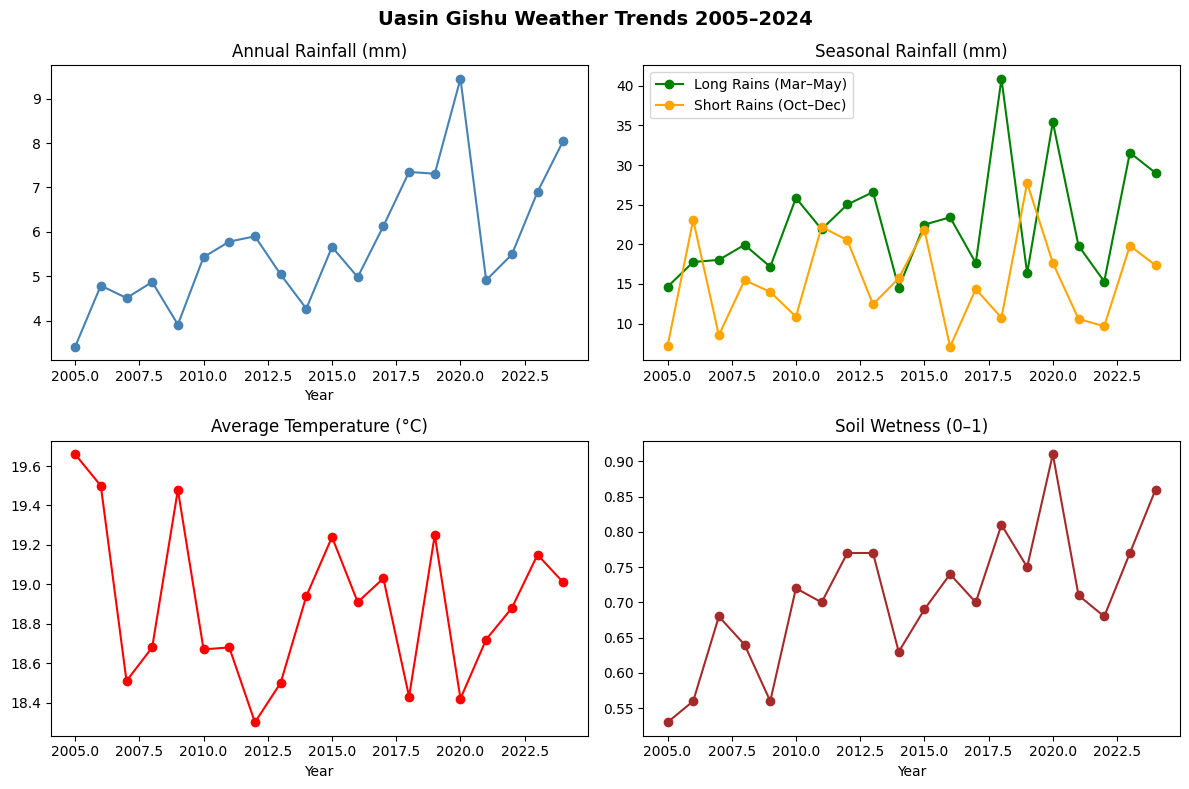

✓ Chart saved to outputs/weather_trends.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Uasin Gishu Weather Trends 2005–2024", fontsize=14, fontweight="bold")

# Rainfall
axes[0,0].plot(df_weather["Year"], df_weather["Rainfall_mm"], color="steelblue", marker="o")
axes[0,0].set_title("Annual Rainfall (mm)")
axes[0,0].set_xlabel("Year")

# Long rains vs Short rains
axes[0,1].plot(df_weather["Year"], df_weather["Rainfall_LongRains_mm"], color="green", marker="o", label="Long Rains (Mar–May)")
axes[0,1].plot(df_weather["Year"], df_weather["Rainfall_ShortRains_mm"], color="orange", marker="o", label="Short Rains (Oct–Dec)")
axes[0,1].set_title("Seasonal Rainfall (mm)")
axes[0,1].legend()

# Temperature
axes[1,0].plot(df_weather["Year"], df_weather["Temp_Avg_C"], color="red", marker="o")
axes[1,0].set_title("Average Temperature (°C)")
axes[1,0].set_xlabel("Year")

# Soil wetness
axes[1,1].plot(df_weather["Year"], df_weather["Soil_Wetness"], color="brown", marker="o")
axes[1,1].set_title("Soil Wetness (0–1)")
axes[1,1].set_xlabel("Year")

plt.tight_layout()
plt.savefig("../outputs/weather_trends.png", dpi=150)
plt.show()
print("✓ Chart saved to outputs/weather_trends.png")

Rainfall — clear upward trend since 2013, with 2020 being an exceptionally wet year (9.5mm). 2005 and 2010 were the driest — expect lower yields those years.
 Seasonal Rainfall — Long Rains are more variable than Short Rains, which makes sense. 2018 and 2020 had unusually high Long Rains — these will likely show high yields.
 Temperature — relatively stable around 18.5–19.5°C, with 2012 being unusually cool. Good — temperature isn't wildly volatile here.
 Soil Wetness — mirrors rainfall closely, trending wetter since 2015. 2020 peak aligns perfectly with the rainfall spike.